In [26]:
!pip install -q groq

### IMPORT LIBRARIES


In [27]:
import os
import json
import random
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from IPython.display import display, Markdown
from kaggle_secrets import UserSecretsClient


### Check the dataset's exact filename

In [28]:
print(os.listdir("/kaggle/input/datasets/lsind18/tarot-json"))

['tarot-images.json', 'cards']


### Load the tarot dataset

In [29]:
data_path = "/kaggle/input/datasets/lsind18/tarot-json/tarot-images.json"  # replace with the exact filename from Step 6 if different

with open(data_path, "r") as f:
    tarot_data = json.load(f)

df = pd.DataFrame(tarot_data["cards"])
print("Loaded", len(df), "cards")
df.head()

Loaded 78 cards


,name,number,arcana,suit,img,fortune_telling,keywords,meanings,Archetype,Hebrew Alphabet,Numerology,Elemental,Mythical/Spiritual,Questions to Ask,Astrology,Affirmation
0,The Fool,0,Major Arcana,Trump,m00.jpg,"[Watch for new projects and new beginnings, Pr...","[freedom, faith, inexperience, innocence]","{'light': ['Freeing yourself from limitation',...",The Divine Madman,Aleph/Ox/1,0 (off the scale; pure potential),Air,Adam before the fall. Christ as a wandering ho...,[What would I do if I felt free to take a leap...,NaN,NaN
1,The Magician,1,Major Arcana,Trump,m01.jpg,"[A powerful man may play a role in your day, Y...","[capability, empowerment, activity]","{'light': ['Taking appropriate action', 'Recei...",The Ego/The Self,Beth/House/2,"1 (origins, unity, seeds)",The Sun/Mercury,"Thoth, the Egyptian god of wisdom, known to th...","[What am I empowered to do?, How might my abil...",NaN,NaN
2,The High Priestess,2,Major Arcana,Trump,m02.jpg,"[A mysterious woman arrives, A sexual secret m...","[intuition, reflection, purity, initiation]",{'light': ['Listening to your feelings and int...,The Virgin/The Maiden,Gimel/Camel/3,"2 (division, debate, duality)",The Moon,"The feminine aspect of divinity, particularity...","[What might a rebel against tradition do?, Wha...",NaN,NaN
3,The Empress,3,Major Arcana,Trump,m03.jpg,"[Pregnancy is in the cards, An opportunity to ...","[fertility, productivity, ripeness, nurturing]","{'light': ['Nurturing yourself and others', 'B...",The Mother,Daleth/Door/4,"3 (expression, productivity, output)",Venus,"Gaia, Mother Earth, Ishtar, DemeterÑmature, re...",[What would a concerned and capable mother do?...,NaN,NaN
4,The Emperor,4,Major Arcana,Trump,m04.jpg,"[A father figure arrives, A new employer or au...","[authority, regulation, direction, structure]","{'light': ['Exercising authority', 'Defining l...",The Father,"He[as]/Window/5, or in some decks, Tzaddi/Fish...","4 (stability, equality, persistence)",Mars/Aries,"Masculine gods, including the Hebrew God, the ...",[How does the issue of control or regulation i...,NaN,NaN


### Set up Groq client


In [30]:
from groq import Groq

user_secrets = UserSecretsClient()
groq_api_key = user_secrets.get_secret("GROQ_API_KEY")

client = Groq(api_key=groq_api_key)
print("Groq client configured successfully")

Groq client configured successfully


### Define spread options

In [31]:
SPREADS = {
    "1": {"name": "Single Card", "positions": ["Answer"]},
    "2": {"name": "Three Card (Past/Present/Future)", "positions": ["Past", "Present", "Future"]}
}

### User picks a spread

In [32]:
def get_user_spread_choice():
    print("Choose a tarot spread:")
    for key, val in SPREADS.items():
        print(f"{key}. {val['name']}")
    choice = input("Enter choice number: ").strip()
    if choice not in SPREADS:
        choice = "2"
    return SPREADS[choice]

chosen_spread = get_user_spread_choice()
print(f"\nYou chose: {chosen_spread['name']}")

Choose a tarot spread:
1. Single Card
2. Three Card (Past/Present/Future)


Enter choice number:  3



You chose: Three Card (Past/Present/Future)


### User confirms the draw

In [33]:
proceed = input("Type 'draw' to shuffle and pick your cards: ").strip().lower()

Type 'draw' to shuffle and pick your cards:  draw


### Card selection engine

In [34]:
def draw_spread(df, n):
    drawn = df.sample(n).reset_index(drop=True)
    drawn["orientation"] = [random.choice(["upright", "reversed"]) for _ in range(n)]
    return drawn

if proceed == "draw":
    n_cards = len(chosen_spread["positions"])
    spread = draw_spread(df, n_cards)
    print("\nCards drawn:")
    print(spread[["name", "orientation"]])
else:
    print("Draw cancelled — re-run Step 11 to try again.")


Cards drawn:
                name orientation
0    Queen of Swords    reversed
1  Page of Pentacles    reversed
2     Seven of Wands     upright


### Pull meaning per card

In [35]:
def get_card_summary(card, orientation):
    meaning_list = card["meanings"]["light"] if orientation == "upright" else card["meanings"]["shadow"]
    return {
        "name": card["name"],
        "orientation": orientation,
        "keywords": ", ".join(card["keywords"][:3]),
        "meaning": random.choice(meaning_list),
        "fortune_telling": random.choice(card["fortune_telling"])
    }

### Generate the LLM reading

In [36]:
def generate_llm_reading(spread, positions):
    card_context = []
    for i, row in spread.iterrows():
        summary = get_card_summary(row, row["orientation"])
        position = positions[i] if i < len(positions) else f"Card {i+1}"
        card_context.append(
            f"{position}: {summary['name']} ({summary['orientation']}) - "
            f"Keywords: {summary['keywords']}. Meaning: {summary['meaning']}"
        )

    prompt = (
        "You are a warm, insightful tarot reader. Based on the following spread, "
        "write a short, natural, personalized reading (150-200 words) that weaves the cards "
        "into one coherent narrative. Do not just repeat the meanings verbatim.\n\n"
        + "\n".join(card_context)
    )

    response = client.chat.completions.create(
        model="llama-3.3-70b-versatile",
        messages=[{"role": "user", "content": prompt}]
    )
    return response.choices[0].message.content

llm_reading = generate_llm_reading(spread, chosen_spread["positions"])
print(llm_reading)

It seems like you've been through a bit of a rough patch, my friend. In the past, I see that you may have used your sharp wit to lash out at others, perhaps unintentionally hurting those around you. This behavior, while possibly a defense mechanism, has likely caused some pain and tension in your relationships. Currently, it appears that you're still navigating some immature or unrefined attitudes towards intimacy and your own desires. This could be holding you back from truly connecting with others on a deeper level. But here's the beautiful thing: I see a strong, brave warrior emerging in your future. You're gearing up to take a stand, to fight for what you believe in, and to assert yourself in a way that's authentic and powerful. This bravery will serve you well, and I have no doubt that you'll rise above any challenges that come your way.


### Display cards + final reading

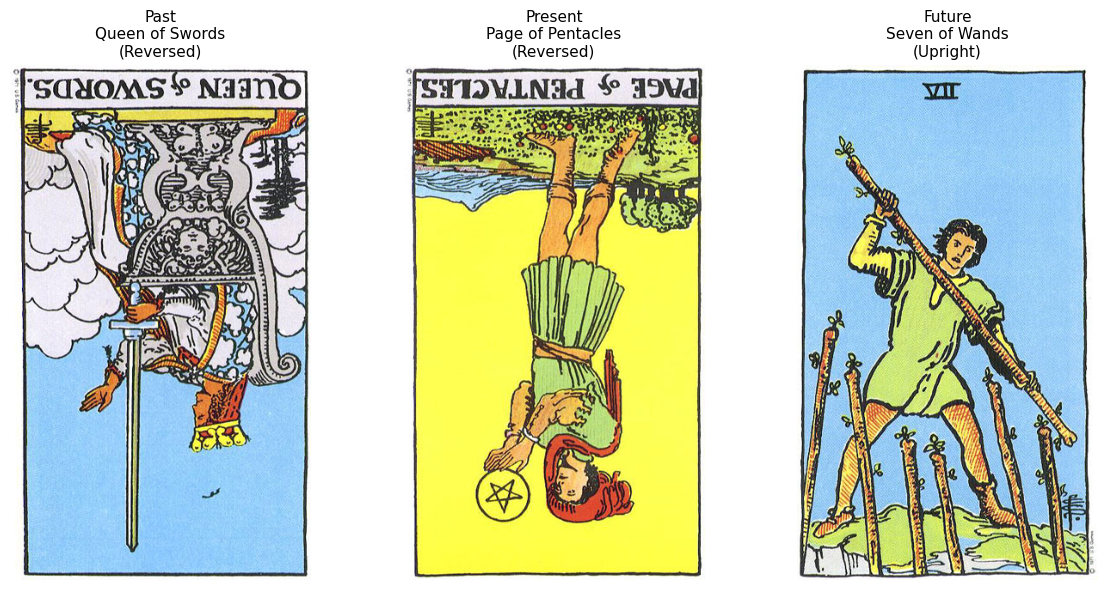

It seems like you've been through a bit of a rough patch, my friend. In the past, I see that you may have used your sharp wit to lash out at others, perhaps unintentionally hurting those around you. This behavior, while possibly a defense mechanism, has likely caused some pain and tension in your relationships. Currently, it appears that you're still navigating some immature or unrefined attitudes towards intimacy and your own desires. This could be holding you back from truly connecting with others on a deeper level. But here's the beautiful thing: I see a strong, brave warrior emerging in your future. You're gearing up to take a stand, to fight for what you believe in, and to assert yourself in a way that's authentic and powerful. This bravery will serve you well, and I have no doubt that you'll rise above any challenges that come your way.

In [37]:
def display_reading(spread, positions, image_folder="/kaggle/input/datasets/lsind18/tarot-json/cards/"):
    n = len(spread)
    fig, axes = plt.subplots(1, n, figsize=(4*n, 6))
    if n == 1:
        axes = [axes]
    for i, row in spread.iterrows():
        img = Image.open(image_folder + row["img"])
        if row["orientation"] == "reversed":
            img = img.rotate(180)
        axes[i].imshow(img)
        axes[i].axis("off")
        axes[i].set_title(f"{positions[i]}\n{row['name']}\n({row['orientation'].capitalize()})", fontsize=11)
    plt.tight_layout()
    plt.show()

display_reading(spread, chosen_spread["positions"])
display(Markdown(llm_reading))